# 소방청 화재발생 통계 × 인구 데이터 분석 프로젝트

## 0단계 - 데이터 소스 선정 및 검증

In [1]:
import pandas as pd
import numpy as np
import re

### 1.1 화재 데이터 로드

In [2]:
fire = pd.read_csv(r'C:\data\소방청_화재발생_정보_20241231.csv', encoding='cp949')
print(f'행 : {fire.shape[0]}, 열 : {fire.shape[1]}')

행 : 191510, 열 : 15


### 1.2 구조 파악

In [3]:
print(fire.info())
print('시도(', fire['시도'].nunique(), '개) :', sorted(fire['시도'].unique()))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 191510 entries, 0 to 191509
Data columns (total 15 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   화재발생년원일    191510 non-null  object 
 1   시도         191510 non-null  object 
 2   시군구        191510 non-null  object 
 3   화재유형       191510 non-null  object 
 4   발화요인대분류    191510 non-null  object 
 5   발화요인소분류    191510 non-null  object 
 6   인명피해(명)소계  191510 non-null  int64  
 7   사망         191510 non-null  int64  
 8   부상         191510 non-null  int64  
 9   재산피해소계     191510 non-null  int64  
 10  부동산        176440 non-null  float64
 11  동산         176440 non-null  float64
 12  장소대분류      191510 non-null  object 
 13  장소중분류      191510 non-null  object 
 14  장소소분류      191510 non-null  object 
dtypes: float64(2), int64(4), object(9)
memory usage: 21.9+ MB
None
시도( 17 개) : ['강원특별자치도', '경기도', '경상남도', '경상북도', '광주광역시', '대구광역시', '대전광역시', '부산광역시', '서울특별시', '세종특별자치시', '울산광역시', '인천광역시', '전라

### ── 1.3 화재 데이터 정제 ──

In [4]:
fire['화재발생년원일'] = pd.to_datetime(fire['화재발생년원일'])
print('날짜 범위 :', fire['화재발생년원일'].min(), '~', fire['화재발생년원일'].max())

fire[['부동산', '동산']] = fire[['부동산', '동산']].fillna(0) # 재산피해 0원인 정상 결측
fire = fire.drop_duplicates().reset_index(drop=True) # 완전중복행 제거
fire['시군구'] = fire['시군구'].str.replace(' ', '', regex=False) # 표기 공백 통일 

날짜 범위 : 2020-01-01 00:03:00 ~ 2024-12-31 23:54:00


### 1.4 시군구 단위 집계

In [5]:
fire_agg = (
    fire.groupby(['시도', '시군구'])
    .agg(화재건수=('화재발생년원일', 'count'),
         사망자수=('사망', 'sum'),
         부상자수=('부상', 'sum'),
         재산피해합계_천원=('재산피해소계', 'sum'))
    .reset_index()
)
print('화재 집계:', fire_agg.shape)

화재 집계: (254, 6)


In [6]:
fire_agg

,시도,시군구,화재건수,사망자수,부상자수,재산피해합계_천원
0,강원특별자치도,강릉시,1186,9,96,83383940
1,강원특별자치도,고성군,336,0,16,4122182
2,강원특별자치도,동해시,339,6,12,3988975
3,강원특별자치도,삼척시,356,7,12,8717131
4,강원특별자치도,속초시,400,2,37,10303772
...,...,...,...,...,...,...
249,충청북도,청주시상당구,503,7,90,3486404
250,충청북도,청주시서원구,498,6,43,31767125
251,충청북도,청주시청원구,686,8,57,22430506
252,충청북도,청주시흥덕구,717,2,29,15701291


### 1.4-2 인구 데이터 로드 및 정제

In [7]:
def load_population(filepath):
    df = pd.read_csv(filepath, encoding='cp949')

    # "서울특별시 종로구 (1111000000)" -> "서울특별시 종로구"
    df['지역명'] = df['행정구역'].apply(lambda s: re.sub(r'\s*\(\d+\)\s*$', '', s).strip())

    # 출장소는 실제 시군구 단위가 아니므로 제외
    df = df[~df['지역명'].str.contains('출장소')].copy()

    # 시도 / 시군구 분리 (하위 구는 공백 없이 붙여서 화재 데이터와 표기 통일)
    tok = df['지역명'].str.split()
    df['시도'] = tok.apply(lambda x: x[0])
    df['시군구'] = tok.apply(lambda x: ''.join(x[1:]) if len(x) > 1 else '__TOTAL__')

    # 2023.6 강원도->강원특별자치도, 2024.1 전라북도 ->전북특별자치도 개편
    # (군위군의 경북->대구 편입은 실제 관할 이동이라 여기서 던드리지 않습니다)
    df['시도'] = df['시도'].replace({'강원도': '강원특별자치도', '전라북도': '전북특별자치도'})

    # 세종 특례 : 시도 총계행을 시군구 '세종'으로도 사용
    sejong = (df['시도'] == '세종특별자치시') & (df['시군구'] == '__TOTAL__')
    df.loc[sejong, '시군구'] = '세종'
    df = df[df['시군구'] != '__TOTAL__']

    pop_cols = [c for c in df.columns if '총인구수' in c]
    for c in pop_cols:
        df[c] = pd.to_numeric(df[c].astype(str).str.replace(',', ''), errors='coerce').fillna(0)

    # 개편으로 나뉜 행을 시도+시군구 기준 합산 (해당 없는 기간은 0이라 sum하면 연속값 복원)
    return df.groupby(['시도', '시군구'])[pop_cols].sum().reset_index(), pop_cols

pop1, cols1 = load_population(r'C:\data\202001_202212_주민등록인구및세대현황_월간.csv')
pop2, cols2 = load_population(r'C:\data\202301_202412_주민등록인구및세대현황_월간.csv')

pop_all = pop1.merge(pop2, on =['시도', '시군구'], how='outer')
pop_all['평균인구_5년'] = pop_all[cols1 + cols2].mean(axis=1).round(2)
pop_final = pop_all[['시도', '시군구', '평균인구_5년']]
print('인구 집계 :', pop_final.shape)

인구 집계 : (265, 3)


In [8]:
pop_final

,시도,시군구,평균인구_5년
0,강원특별자치도,강릉시,211402.15
1,강원특별자치도,고성군,27112.33
2,강원특별자치도,동해시,89429.30
3,강원특별자치도,삼척시,63830.78
4,강원특별자치도,속초시,82248.22
...,...,...,...
260,충청북도,청주시상당구,194210.83
261,충청북도,청주시서원구,191282.87
262,충청북도,청주시청원구,192875.42
263,충청북도,청주시흥덕구,270213.40


### 1.5 최종 병합 및 파생변수

In [9]:
analysis = fire_agg.merge(pop_final, on=['시도', '시군구'], how='left')
print('병합 안 된 지역 수 :', analysis['평균인구_5년'].isna().sum()) # 0이어야 정상

analysis['화재발생율_10만명당'] = (analysis['화재건수'] / analysis['평균인구_5년'] * 100000).round(2)
print(analysis.sort_values('화재발생율_10만명당', ascending=False).head())

# SAS로 넘길 파일 저장 (칼럼명은 영문/ASCII로 - 32바이트 문제 재발 방지)
analysis.rename(columns={
    '시도': 'SIDO', '시군구': 'SIGUNGU', '화재건수': 'FIRE_CNT',
    '사망자수': 'DEATH_CNT', '부상자수': 'INJURY_CNT',
    '재산피해합계_천원': 'DMG_TOTAL_SUM', '평균인구_5년': 'POP_AVG_5YR',
    '화재발생율_10만명당': 'FIRE_RATE_100K'
}).to_csv(r'C:\data\fire_population_analysis.csv', index=False, encoding='utf-8-sig')

병합 안 된 지역 수 : 0
       시도  시군구  화재건수  사망자수  부상자수  재산피해합계_천원   평균인구_5년  화재발생율_10만명당
72   경상남도  의령군   428     3    13    4207679  26143.18      1637.14
204  전라남도  함평군   502     4    10    5509405  31180.20      1610.00
87   경상북도  고령군   455     1    18    4362383  30683.92      1482.86
70   경상남도  산청군   504     4    21    6312527  34264.27      1470.92
199  전라남도  영암군   774     5    15    8793031  52905.27      1462.99


### 1.6 SAS 연동용 파일 내보내기
- SAS에서 직접 집계·조인 연습을 할 수 있도록 (1) 정제만 된 화재 원자료와
(2) 인구 요약 테이블을 각각 영문 컬럼명으로 내보낸다. 

In [10]:
# (1) 화재 원자료 - 정제만 하고 집계는 SAS에서 직접
rename_map = {
    '화재발생년원일': 'FIRE_DT', '시도': 'SIDO', '시군구': 'SIGUNGU',
    '화재유형': 'FIRE_TYPE', '발화요인대분류': 'CAUSE_L', '발화요인소분류': 'CAUSE_S',
    '인명피해(명)소계': 'CASUALTY', '사망': 'DEATH', '부상': 'INJURY',
    '재산피해소계': 'DMG_TOTAL', '부동산': 'DMG_REAL', '동산': 'DMG_MOVABLE',
    '장소대분류': 'PLACE_L', '장소중분류': 'PLACE_M', '장소소분류': 'PLACE_S'
}
fire.rename(columns=rename_map).to_csv(
    r'C:\data\fire_clean_for_sas.csv', index=False, encoding='utf-8-sig'
)

# (2) 인구 요약 테이블
pop_final.rename(columns={
    '시도': 'SIDO', '시군구': 'SIGUNGU', '평균인구_5년': 'POP_AVG_5YR'
}).to_csv(r'C:\data\population_sigungu_avg.csv', index=False, encoding='utf-8-sig')

### 2.1 데이터 탐색 - 기초 통계량
- 평균과 중앙값의 차이로 왜도(치우침)를 먼저 확인한다.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

In [12]:
df = pd.read_csv(r'C:\data\fire_population_analysis.csv', encoding='utf-8-sig')
print(df.shape)

num_cols = ['FIRE_CNT', 'DEATH_CNT', 'INJURY_CNT', 'DMG_TOTAL_SUM', 'POP_AVG_5YR', 'FIRE_RATE_100K']
stats = df[num_cols].describe().T
stats['skew'] = df[num_cols].skew()
print(stats[['mean', '50%', 'std', 'min', 'max', 'skew']])

(254, 8)
                        mean          50%           std        min  \
FIRE_CNT        7.539724e+02      685.000  4.295342e+02      43.00   
DEATH_CNT       6.196850e+00        5.000  5.681312e+00       0.00   
INJURY_CNT      4.089370e+01       35.000  2.906964e+01       2.00   
DMG_TOTAL_SUM   1.829500e+07  6502357.000  4.498143e+07  271327.00   
POP_AVG_5YR     2.059761e+05   175483.105  1.698568e+05    9087.40   
FIRE_RATE_100K  5.789799e+02      415.690  3.719492e+02      56.82   

                         max      skew  
FIRE_CNT        3.122000e+03  1.404143  
DEATH_CNT       5.700000e+01  4.264893  
INJURY_CNT      2.000000e+02  1.318516  
DMG_TOTAL_SUM   5.710219e+08  8.341008  
POP_AVG_5YR     8.989902e+05  1.068927  
FIRE_RATE_100K  1.637140e+03  0.774017  


### 2.1-2 이상치 탐색 (IQR 기준)

In [13]:
def iqr_outliers(s):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return (s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)

for col in ['FIRE_CNT', 'DMG_TOTAL_SUM', 'FIRE_RATE_100K']:
    mask = iqr_outliers(df[col])
    print(f'\n[{col}] 이상치 {mask.sum()}개')
    print(df.loc[mask, ['SIDO', 'SIGUNGU', col]].sort_values(col, ascending=False))


[FIRE_CNT] 이상치 6개
      SIDO SIGUNGU  FIRE_CNT
62     경기도     화성시      3122
66    경상남도     김해시      2267
59     경기도     평택시      2254
144  서울특별시     강남구      2024
28     경기도    남양주시      1971
27     경기도     김포시      1953

[DMG_TOTAL_SUM] 이상치 26개
        SIDO  SIGUNGU  DMG_TOTAL_SUM
57       경기도      이천시      571021859
62       경기도      화성시      201379193
123    대전광역시      대덕구      186222100
102     경상북도      울진군      176293907
60       경기도      포천시      142127857
28       경기도     남양주시      138896424
27       경기도      김포시      105196955
58       경기도      파주시      103573712
181    인천광역시       서구       93974529
42       경기도   안산시단원구       93531629
54       경기도   용인시처인구       87803502
0    강원특별자치도      강릉시       83383940
59       경기도      평택시       81390054
88      경상북도      구미시       75802059
44       경기도      안성시       63080574
170    울산광역시       남구       62770190
41       경기도      시흥시       62138204
47       경기도      양주시       61225036
24       경기도      광주시       57084063
173    울산광역시 

### 2.1-3 분포 시각화

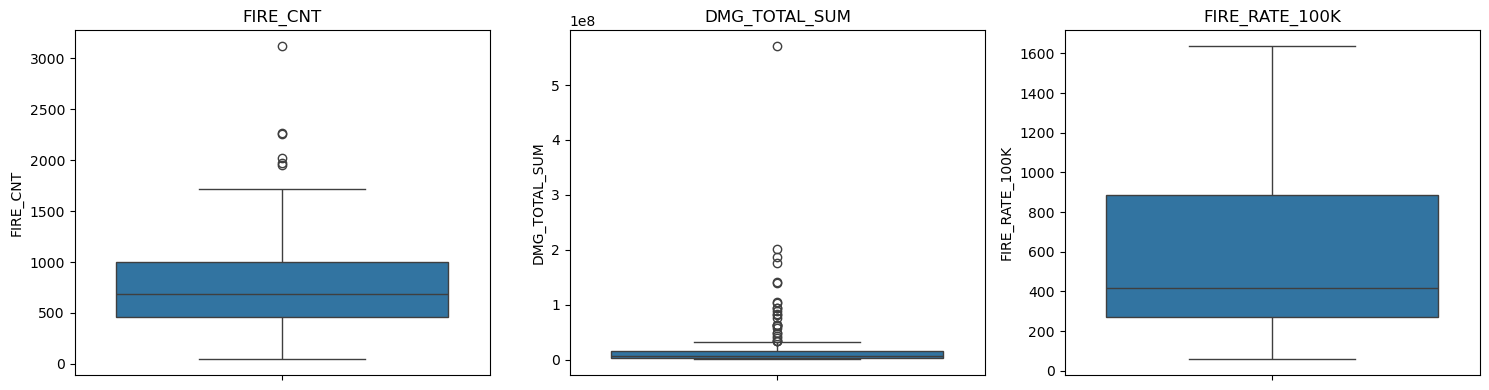

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['FIRE_CNT', 'DMG_TOTAL_SUM', 'FIRE_RATE_100K']):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

### 2.1-4 변수간 상관분석 (Spearman)
- 카운트·금액 변수가 치우쳐 있으므로 순위 기반 상관계수를 사용한다.

                FIRE_CNT  DEATH_CNT  INJURY_CNT  DMG_TOTAL_SUM  POP_AVG_5YR  \
FIRE_CNT           1.000      0.651       0.759          0.475        0.771   
DEATH_CNT          0.651      1.000       0.598          0.421        0.502   
INJURY_CNT         0.759      0.598       1.000          0.437        0.732   
DMG_TOTAL_SUM      0.475      0.421       0.437          1.000        0.240   
POP_AVG_5YR        0.771      0.502       0.732          0.240        1.000   
FIRE_RATE_100K    -0.280     -0.183      -0.424          0.076       -0.794   

                FIRE_RATE_100K  
FIRE_CNT                -0.280  
DEATH_CNT               -0.183  
INJURY_CNT              -0.424  
DMG_TOTAL_SUM            0.076  
POP_AVG_5YR             -0.794  
FIRE_RATE_100K           1.000  


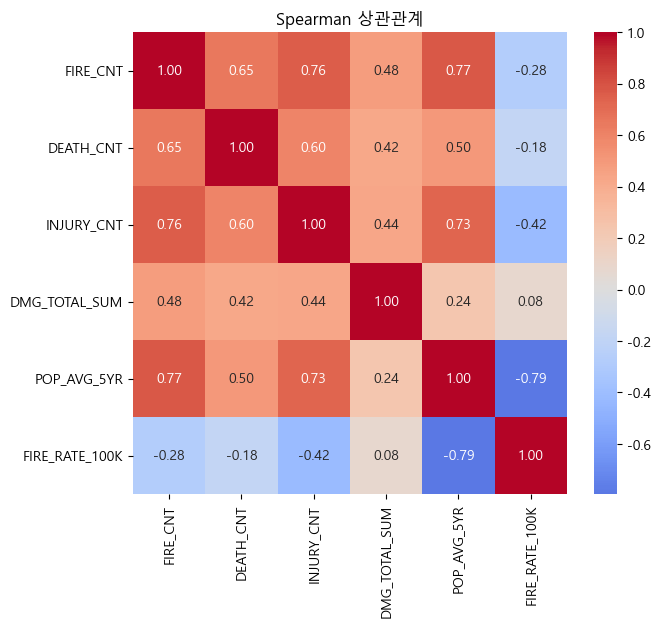

In [17]:
corr = df[num_cols].corr(method='spearman')
print(corr.round(3))

plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Spearman 상관관계')
plt.show()